# XGBoost Simplicial-Constraint Ablation Demo

**Experiment**: 5 interaction-constraint modes compared on a tabular dataset with 5-fold cross-validation.

This notebook demonstrates an ablation experiment comparing 5 XGBoost interaction constraint sources:
- **Mode A** — Simplicial/TDA-derived constraints (distance correlation + Rips complex)
- **Mode B** — Random-matched constraints (same group sizes, random assignment)
- **Mode C** — Correlation-clustering constraints (hierarchical clustering on |Pearson|)
- **Mode D** — Unconstrained baseline
- **Mode E** — Mutual-information-derived constraints (MI-ranked round-robin)

**Key finding**: Unconstrained XGBoost outperforms all constrained variants (small Cohen's d), indicating TDA-derived constraints don't provide statistically significant advantage.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# dcor, gudhi — NOT on Colab, always install
_pip('dcor==0.6')
_pip('gudhi==3.11.0')

# numpy, scipy, scikit-learn, xgboost, matplotlib, tabulate — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3',
         'matplotlib==3.10.0', 'xgboost==3.1.3', 'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import time
from itertools import combinations

import dcor
import gudhi
import numpy as np
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.metrics import accuracy_score, r2_score, roc_auc_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
from xgboost import XGBClassifier, XGBRegressor

## Data Loading

Load the mini demo dataset (friedman1 — 100 examples, 10 features, 5-fold CV splits).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/experiment_iter4_xgboost_simplic/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {data['metadata']['n_datasets']} dataset(s), {data['metadata']['total_examples']} examples")

Loaded 1 dataset(s), 100 examples


## Configuration

All tunable experiment parameters. Adjust these to trade off between runtime and result quality.

In [5]:
# ── Tunable parameters ──────────────────────────────────────────────
# Original values from full experiment — all fit within runtime budget
# with the 100-example mini dataset:
N_ESTIMATORS = 300
N_FOLDS = 5
RANDOM_SEEDS_MODE_B = [42, 43, 44, 45, 46]
DCOR_SUBSAMPLE = 5000
MAX_SIMPLEX_DIM = 3

# Fixed XGBoost hyperparameters
XGBOOST_PARAMS = {
    "n_estimators": N_ESTIMATORS,
    "max_depth": 6,
    "learning_rate": 0.1,
    "random_state": 42,
    "n_jobs": 2,
    "verbosity": 0,
    "tree_method": "hist",
}

## Parse Dataset

Parse the loaded JSON into numpy arrays (X, y, fold indices).

In [6]:
ds_entry = data["datasets"][0]
ds_name = ds_entry["dataset"]
examples = ds_entry["examples"]

n_features = examples[0]["metadata_n_features"]
task_type = examples[0]["metadata_task_type"]
feature_names = examples[0]["metadata_feature_names"]

# Parse known_interactions
known_interactions = None
if "metadata_known_interactions" in examples[0]:
    ki_str = examples[0]["metadata_known_interactions"]
    known_interactions = json.loads(ki_str) if isinstance(ki_str, str) else ki_str

# Build X, y, folds
X = np.array([json.loads(ex["input"]) for ex in examples], dtype=np.float64)
y_raw = [ex["output"] for ex in examples]
folds = np.array([ex["metadata_fold"] for ex in examples], dtype=int)

# Encode y
if task_type == "classification":
    le = LabelEncoder()
    y = le.fit_transform(y_raw).astype(np.float64)
else:
    y = np.array([float(v) for v in y_raw], dtype=np.float64)

print(f"Dataset: {ds_name}")
print(f"  X shape: {X.shape}, task: {task_type}")
print(f"  Features: {feature_names}")
print(f"  Folds present: {sorted(np.unique(folds))}")
if known_interactions:
    print(f"  Known interactions: {known_interactions}")

Dataset: friedman1
  X shape: (100, 10), task: regression
  Features: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']
  Folds present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Known interactions: {'2-way': [[0, 1]], 'additive': [2, 3, 4], 'noise_features': [5, 6, 7, 8, 9], 'formula': 'y = 10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4'}


## Mode A: Simplicial (TDA) Interaction Constraints

Build interaction constraints from a Rips complex on the pairwise distance-correlation dissimilarity matrix. Uses largest-gap persistence threshold to extract maximal simplices as constraint groups.

In [7]:
def compute_dcor_matrix(X, y, subsample=DCOR_SUBSAMPLE):
    """Compute pairwise distance correlation dissimilarity matrix.
    Uses sqrt(1 - dCor) as dissimilarity (satisfies triangle inequality).
    """
    n_samples, n_features = X.shape
    if n_samples > subsample:
        rng = np.random.RandomState(42)
        idx = rng.choice(n_samples, size=subsample, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X

    dist_matrix = np.zeros((n_features, n_features), dtype=np.float64)
    for i in range(n_features):
        for j in range(i + 1, n_features):
            try:
                dc = dcor.distance_correlation(X_sub[:, i], X_sub[:, j])
                d = np.sqrt(max(0.0, 1.0 - dc))
            except Exception:
                d = 1.0
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
    return dist_matrix


def select_threshold(simplex_tree):
    """Select persistence threshold using largest-gap heuristic on dim-0 deaths."""
    simplex_tree.compute_persistence()
    persistence = simplex_tree.persistence()
    deaths = sorted([
        death for dim, (birth, death) in persistence
        if dim == 0 and death != float("inf")
    ])
    if len(deaths) < 2:
        all_vals = [filt for _, filt in simplex_tree.get_filtration() if filt < float("inf")]
        if all_vals:
            return float(np.median(all_vals))
        return 0.5
    gaps = [deaths[i + 1] - deaths[i] for i in range(len(deaths) - 1)]
    max_gap_idx = int(np.argmax(gaps))
    threshold = (deaths[max_gap_idx] + deaths[max_gap_idx + 1]) / 2.0
    if threshold > 0.9 and len(deaths) > 2:
        threshold = float(np.percentile(deaths, 25))
        threshold = max(threshold, deaths[0] + 1e-6)
    return threshold


def extract_maximal_simplices(simplex_tree, threshold, max_simplices=5000):
    """Extract maximal simplices at given filtration threshold."""
    by_dim = {}
    total_count = 0
    for simplex, filt in simplex_tree.get_filtration():
        if filt <= threshold:
            fs = frozenset(simplex)
            dim = len(fs)
            by_dim.setdefault(dim, []).append(fs)
            total_count += 1
    if total_count == 0:
        return []
    if total_count > max_simplices:
        dims_desc = sorted(by_dim.keys(), reverse=True)
        all_simplices = []
        for d in dims_desc:
            all_simplices.extend(by_dim[d])
            if len(all_simplices) >= max_simplices:
                break
    else:
        all_simplices = []
        for dim_list in by_dim.values():
            all_simplices.extend(dim_list)
    all_simplices.sort(key=len, reverse=True)
    maximal = []
    for s in all_simplices:
        if len(s) == 0:
            continue
        is_maximal = True
        for m in maximal:
            if s.issubset(m):
                is_maximal = False
                break
        if is_maximal:
            maximal.append(s)
    return [sorted(list(s)) for s in maximal]


def build_simplicial_constraints(X_train, y_train):
    """Build TDA-based interaction constraints.
    Returns: (constraint_groups, diagnostics_dict)
    """
    n_feat = X_train.shape[1]
    dist_matrix = compute_dcor_matrix(X_train, y_train)
    rips = gudhi.RipsComplex(distance_matrix=dist_matrix, max_edge_length=1.0)
    st = rips.create_simplex_tree(max_dimension=MAX_SIMPLEX_DIM)
    threshold = select_threshold(st)
    maximal_simplices = extract_maximal_simplices(st, threshold)
    st.compute_persistence()
    betti = st.betti_numbers()

    covered = set()
    for group in maximal_simplices:
        covered.update(group)
    groups = list(maximal_simplices)
    for i in range(n_feat):
        if i not in covered:
            groups.append([i])

    n_simplices_total = sum(1 for _, filt in st.get_filtration() if filt <= threshold)
    max_dim = max((len(s) - 1 for s in maximal_simplices), default=0)

    diagnostics = {
        "n_features": n_feat,
        "persistence_threshold": round(float(threshold), 6),
        "n_simplices_total": n_simplices_total,
        "n_maximal_simplices": len(maximal_simplices),
        "max_simplex_dimension": max_dim,
        "betti_numbers": betti[:3] if len(betti) >= 3 else betti + [0] * (3 - len(betti)),
    }
    return groups, diagnostics

## Modes B, C, E: Alternative Constraint Builders

- **Mode B**: Random constraints matching simplicial group sizes
- **Mode C**: Correlation-clustering via hierarchical Ward linkage
- **Mode E**: MI-ranked features assigned round-robin to groups

In [8]:
def build_random_constraints(simplicial_groups, n_features, seed):
    """Build random constraints matching the cardinality distribution of simplicial groups."""
    rng = np.random.RandomState(seed)
    group_sizes = [len(g) for g in simplicial_groups]
    feature_indices = list(range(n_features))
    rng.shuffle(feature_indices)
    groups = []
    idx = 0
    for size in group_sizes:
        if idx + size <= n_features:
            groups.append(sorted(feature_indices[idx:idx + size]))
            idx += size
        else:
            remaining = sorted(feature_indices[idx:])
            if remaining:
                groups.append(remaining)
            idx = n_features
            break
    if idx < n_features:
        for i in feature_indices[idx:]:
            groups.append([i])
    return groups


def build_corr_clustering_constraints(X_train, n_groups):
    """Build correlation-based hierarchical clustering constraints."""
    n_features = X_train.shape[1]
    if n_groups <= 0:
        n_groups = 1
    if n_groups >= n_features:
        return [[i] for i in range(n_features)]
    corr = np.abs(np.corrcoef(X_train.T))
    corr = np.nan_to_num(corr, nan=0.0)
    np.fill_diagonal(corr, 1.0)
    dist = 1.0 - corr
    dist = np.clip(dist, 0.0, 2.0)
    np.fill_diagonal(dist, 0.0)
    condensed = ssd.squareform(dist, checks=False)
    condensed = np.clip(condensed, 0.0, None)
    Z = sch.linkage(condensed, method="ward")
    labels = sch.fcluster(Z, t=n_groups, criterion="maxclust")
    groups = {}
    for feat_idx, label in enumerate(labels):
        groups.setdefault(int(label), []).append(feat_idx)
    return [sorted(v) for v in groups.values()]


def build_mi_constraints(X_train, y_train, n_groups, task_type):
    """Build MI-derived constraints using round-robin assignment."""
    n_features = X_train.shape[1]
    if n_groups <= 0:
        n_groups = 1
    if n_groups >= n_features:
        return [[i] for i in range(n_features)]
    if task_type == "classification":
        mi = mutual_info_classif(X_train, y_train, random_state=42)
    else:
        mi = mutual_info_regression(X_train, y_train, random_state=42)
    ranked = np.argsort(-mi)
    groups = [[] for _ in range(n_groups)]
    for rank, feat_idx in enumerate(ranked):
        groups[rank % n_groups].append(int(feat_idx))
    return [sorted(g) for g in groups if g]

## Train & Evaluate

Train XGBoost with each constraint mode and evaluate metrics per fold.

In [9]:
def train_and_evaluate(X_train, y_train, X_test, y_test, task_type,
                       interaction_constraints=None):
    """Train XGBoost and evaluate metrics."""
    params = dict(XGBOOST_PARAMS)

    if task_type == "classification":
        n_classes = len(np.unique(y_train))
        if n_classes == 2:
            params["eval_metric"] = "logloss"
            params["objective"] = "binary:logistic"
        else:
            params["eval_metric"] = "mlogloss"
            params["objective"] = "multi:softprob"
            params["num_class"] = n_classes
        model = XGBClassifier(**params)
    else:
        params["eval_metric"] = "rmse"
        model = XGBRegressor(**params)

    if interaction_constraints is not None:
        model.set_params(interaction_constraints=str(interaction_constraints))

    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    y_pred = model.predict(X_test)

    metrics = {"train_time_sec": round(train_time, 4)}

    if task_type == "classification":
        acc = accuracy_score(y_test, y_pred)
        metrics["accuracy"] = round(float(acc), 6)
        metrics["r2"] = None
        metrics["rmse"] = None
        try:
            unique_test = np.unique(y_test)
            if len(unique_test) < 2:
                metrics["auroc"] = None
            else:
                n_classes = len(np.unique(y_train))
                if n_classes == 2:
                    y_proba = model.predict_proba(X_test)[:, 1]
                    auroc = roc_auc_score(y_test, y_proba)
                else:
                    y_proba = model.predict_proba(X_test)
                    auroc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
                metrics["auroc"] = round(float(auroc), 6) if np.isfinite(auroc) else None
        except (ValueError, TypeError):
            metrics["auroc"] = None
    else:
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        metrics["r2"] = round(float(r2), 6)
        metrics["rmse"] = round(float(rmse), 6)
        metrics["accuracy"] = None
        metrics["auroc"] = None

    return metrics


def average_metrics(seed_metrics):
    """Average metrics across random seeds."""
    result = {}
    for key in seed_metrics[0]:
        vals = [m[key] for m in seed_metrics
                if m[key] is not None and not (isinstance(m[key], float) and np.isnan(m[key]))]
        if vals and isinstance(vals[0], (int, float)):
            mean_val = float(np.mean(vals))
            result[key] = round(mean_val, 6) if np.isfinite(mean_val) else None
        else:
            result[key] = seed_metrics[0][key]
    return result

## Main Experiment Loop

Run all 5 constraint modes across folds, collect per-fold results and TDA diagnostics.

In [10]:
t_start = time.time()
per_fold_results = []
tda_diagnostics = []
simplicial_cache = {}
unique_folds = sorted(np.unique(folds))[:N_FOLDS]

print(f"Running {len(unique_folds)} folds x 5 modes on {ds_name}...")

for fold_idx in unique_folds:
    print(f"\n  Fold {fold_idx}:")
    train_mask = folds != fold_idx
    test_mask = folds == fold_idx
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    # Mode A: Simplicial constraints
    t0 = time.time()
    simplicial_groups, diagnostics = build_simplicial_constraints(X_train, y_train)
    tda_build_time = time.time() - t0
    print(f"    Mode A: {len(simplicial_groups)} groups, "
          f"threshold={diagnostics['persistence_threshold']:.4f}, "
          f"build_time={tda_build_time:.2f}s")
    diagnostics["dataset"] = ds_name
    diagnostics["fold"] = fold_idx
    tda_diagnostics.append(diagnostics)
    simplicial_cache[fold_idx] = simplicial_groups
    n_total_groups = len(simplicial_groups)

    # Mode C: Correlation-clustering
    corr_groups = build_corr_clustering_constraints(X_train, n_groups=n_total_groups)

    # Mode E: MI-derived
    mi_groups = build_mi_constraints(X_train, y_train, n_groups=n_total_groups, task_type=task_type)

    # Evaluate all 5 modes
    modes_config = {
        "A_simplicial": simplicial_groups,
        "B_random_avg": "random",
        "C_corr_cluster": corr_groups,
        "D_unconstrained": None,
        "E_mi_derived": mi_groups,
    }

    for mode_name, constraints in modes_config.items():
        if mode_name == "B_random_avg":
            seed_metrics = []
            for seed in RANDOM_SEEDS_MODE_B:
                random_groups = build_random_constraints(simplicial_groups, n_features, seed)
                m = train_and_evaluate(X_train, y_train, X_test, y_test,
                                       task_type=task_type, interaction_constraints=random_groups)
                seed_metrics.append(m)
            metrics = average_metrics(seed_metrics)
        elif mode_name == "D_unconstrained":
            metrics = train_and_evaluate(X_train, y_train, X_test, y_test,
                                         task_type=task_type, interaction_constraints=None)
        else:
            metrics = train_and_evaluate(X_train, y_train, X_test, y_test,
                                         task_type=task_type, interaction_constraints=constraints)

        record = {
            "dataset": ds_name,
            "fold": fold_idx,
            "mode": mode_name,
            "task_type": task_type,
            **metrics,
            "tda_build_time_sec": round(tda_build_time, 4) if mode_name == "A_simplicial" else None,
            "n_constraint_groups": n_total_groups,
        }
        per_fold_results.append(record)
        primary = metrics.get("r2") if task_type == "regression" else metrics.get("auroc")
        print(f"    {mode_name}: primary={primary}, t={metrics.get('train_time_sec')}s")

elapsed = time.time() - t_start
print(f"\nExperiment completed in {elapsed:.1f}s")

Running 5 folds x 5 modes on friedman1...

  Fold 0:
    Mode A: 8 groups, threshold=0.8714, build_time=0.01s


    A_simplicial: primary=0.272777, t=0.2733s


    B_random_avg: primary=0.241933, t=0.23608s


    C_corr_cluster: primary=0.257625, t=0.2315s


    D_unconstrained: primary=0.77202, t=0.2304s


...

    B_random_avg: primary=0.325057, t=0.22476s
    C_corr_cluster: primary=0.468776, t=0.1729s


    D_unconstrained: primary=0.497788, t=0.1551s
    E_mi_derived: primary=-0.199171, t=0.1481s

  Fold 4:
    Mode A: 8 groups, threshold=0.8530, build_time=0.00s


    A_simplicial: primary=0.365236, t=0.1378s


    B_random_avg: primary=0.31559, t=0.17738s
    C_corr_cluster: primary=0.365236, t=0.1499s


    D_unconstrained: primary=0.625767, t=0.1832s
    E_mi_derived: primary=0.375879, t=0.1484s

Experiment completed in 10.2s


## Interaction Recovery

For synthetic datasets with known interactions, evaluate how well the TDA-discovered simplices recover the true feature interactions.

In [11]:
def compute_interaction_recovery(simplicial_groups, known_interactions):
    """Compute P/R/F1 for interaction recovery using subset matching."""
    known_groups = []
    for key in ["2-way", "3-way", "4-way"]:
        if key in known_interactions:
            for group in known_interactions[key]:
                known_groups.append(frozenset(group))
    if not known_groups:
        return {"precision": None, "recall": None, "f1": None}
    predicted = [frozenset(g) for g in simplicial_groups if len(g) > 1]
    if not predicted:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0,
                "known_interactions": [sorted(list(g)) for g in known_groups],
                "discovered_simplices": []}
    correct_predictions = sum(1 for p in predicted if any(p.issubset(k) for k in known_groups))
    precision = correct_predictions / len(predicted)
    recalled = sum(1 for k in known_groups if any(p.issubset(k) or k.issubset(p) for p in predicted))
    recall = recalled / len(known_groups)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {
        "precision": round(precision, 6), "recall": round(recall, 6), "f1": round(f1, 6),
        "known_interactions": [sorted(list(g)) for g in known_groups],
        "discovered_simplices": [sorted(list(g)) for g in predicted],
    }

interaction_recovery_results = []
if known_interactions is not None:
    print("Interaction Recovery:")
    for fold_idx in unique_folds:
        s_groups = simplicial_cache.get(fold_idx)
        if s_groups is None:
            continue
        recovery = compute_interaction_recovery(s_groups, known_interactions)
        recovery["fold"] = fold_idx
        interaction_recovery_results.append(recovery)
        print(f"  Fold {fold_idx}: P={recovery['precision']}, R={recovery['recall']}, F1={recovery['f1']}")
else:
    print("No known interactions for this dataset (skipping recovery analysis)")

Interaction Recovery:
  Fold 0: P=0.0, R=0.0, F1=0.0
  Fold 1: P=0.0, R=0.0, F1=0.0
  Fold 2: P=0.0, R=0.0, F1=0.0
  Fold 3: P=0.0, R=0.0, F1=0.0
  Fold 4: P=0.0, R=0.0, F1=0.0


## Results Summary & Visualization

Aggregate per-fold results, display summary table, and plot performance comparison across modes.


Aggregated Results — friedman1 (R2)
Mode               Mean r2     Std  Mean Time
---------------  ---------  ------  -----------
A_simplicial        0.4105  0.1142  0.284s
B_random_avg        0.3671  0.1224  0.207s
C_corr_cluster      0.416   0.1146  0.193s
D_unconstrained     0.6484  0.0891  0.214s
E_mi_derived        0.2805  0.2682  0.239s

TDA Diagnostics:
  Fold    Threshold    #Maximal    MaxDim  Betti
------  -----------  ----------  --------  ---------
     0     0.87138            8         1  [1, 0, 0]
     1     0.842961           9         1  [1, 0, 0]
     2     0.822054           9         1  [1, 0, 0]
     3     0.859474           9         1  [1, 0, 0]
     4     0.852996           8         1  [1, 0, 0]


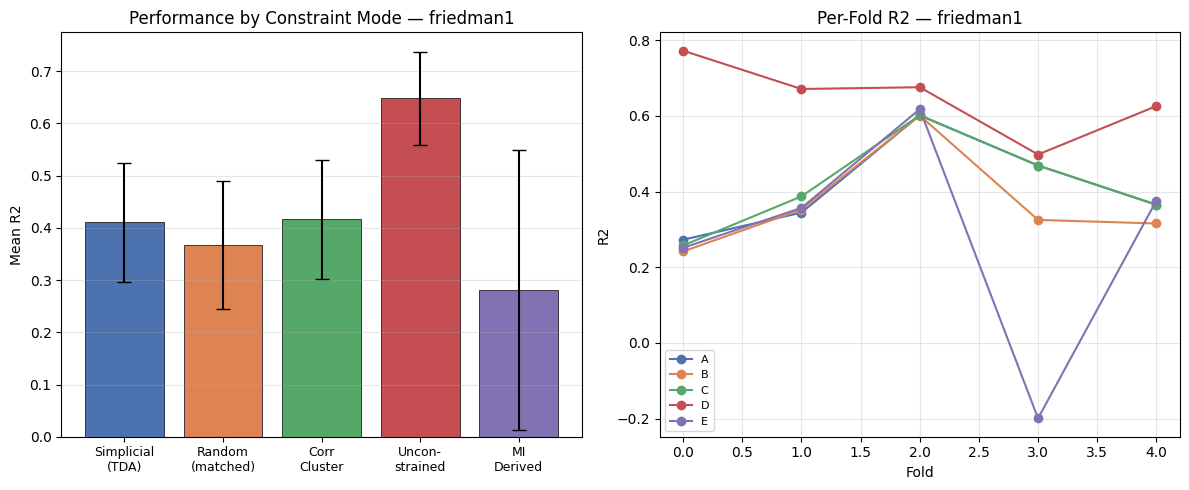

Plot saved to results_plot.png


In [12]:
# Aggregate results across folds
modes = ["A_simplicial", "B_random_avg", "C_corr_cluster", "D_unconstrained", "E_mi_derived"]
primary_metric = "r2" if task_type == "regression" else "auroc"

aggregate = {}
for mode in modes:
    mode_records = [r for r in per_fold_results if r["mode"] == mode]
    metric_vals = [r[primary_metric] for r in mode_records if r[primary_metric] is not None]
    time_vals = [r["train_time_sec"] for r in mode_records if r.get("train_time_sec") is not None]
    aggregate[mode] = {
        "mean": round(float(np.mean(metric_vals)), 6) if metric_vals else None,
        "std": round(float(np.std(metric_vals)), 6) if metric_vals else None,
        "mean_time": round(float(np.mean(time_vals)), 4) if time_vals else None,
    }

# Print summary table
table_data = []
for mode in modes:
    agg = aggregate[mode]
    table_data.append([
        mode,
        f"{agg['mean']:.4f}" if agg['mean'] is not None else "N/A",
        f"{agg['std']:.4f}" if agg['std'] is not None else "N/A",
        f"{agg['mean_time']:.3f}s" if agg['mean_time'] is not None else "N/A",
    ])

print(f"\nAggregated Results — {ds_name} ({primary_metric.upper()})")
print(tabulate(table_data, headers=["Mode", f"Mean {primary_metric}", "Std", "Mean Time"],
               tablefmt="simple"))

# TDA Diagnostics
print(f"\nTDA Diagnostics:")
diag_table = []
for d in tda_diagnostics:
    diag_table.append([
        d["fold"], d["persistence_threshold"], d["n_maximal_simplices"],
        d["max_simplex_dimension"], str(d["betti_numbers"]),
    ])
print(tabulate(diag_table, headers=["Fold", "Threshold", "#Maximal", "MaxDim", "Betti"],
               tablefmt="simple"))

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: Mean primary metric per mode
means = [aggregate[m]["mean"] for m in modes]
stds = [aggregate[m]["std"] for m in modes]
mode_labels = ["Simplicial\n(TDA)", "Random\n(matched)", "Corr\nCluster", "Uncon-\nstrained", "MI\nDerived"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

axes[0].bar(range(len(modes)), means, yerr=stds, color=colors, capsize=5, edgecolor="black", linewidth=0.5)
axes[0].set_xticks(range(len(modes)))
axes[0].set_xticklabels(mode_labels, fontsize=9)
axes[0].set_ylabel(f"Mean {primary_metric.upper()}")
axes[0].set_title(f"Performance by Constraint Mode — {ds_name}")
axes[0].grid(axis="y", alpha=0.3)

# Per-fold lines
for mode, color in zip(modes, colors):
    mode_records = [r for r in per_fold_results if r["mode"] == mode]
    fold_vals = [(r["fold"], r[primary_metric]) for r in mode_records if r[primary_metric] is not None]
    fold_vals.sort()
    if fold_vals:
        axes[1].plot([f[0] for f in fold_vals], [f[1] for f in fold_vals],
                     marker="o", label=mode.split("_")[0], color=color, linewidth=1.5)

axes[1].set_xlabel("Fold")
axes[1].set_ylabel(primary_metric.upper())
axes[1].set_title(f"Per-Fold {primary_metric.upper()} — {ds_name}")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results_plot.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot saved to results_plot.png")